# Phân tích dữ liệu và các yếu tố tác động đến giá nhà trọ
## 1. Phát biểu bài toán 
- Mục tiêu của bài toán là Khảo sát dữ liệu về phòng trọ sinh viên tại 3 thành phố Đà Nẵng, Hà Nội và Hồ Chí Minh nhằm xác định các đặc trưng quan trọng ảnh hưởng đến giá thuê phòng trọ. Từ đó, đánh giá tính khả thi cho việc xây dựng mô hình dự đoán với biến mục tiêu (target variable) $Y$ là Giá cho thuê từ các biến/đặc trưng $X_i$ (Diện tích, vị trí, tiện ích).
- Loại bài toán mô hinh hóa: Do biến mục tiêu $Y$ (Giá cho thuê) đã được xác định cụ thể và là một biến số thực (liên tục), nên việc mô hình hóa ở tương lại sẽ là bài toán Hồi quy (Regression).
- Tính khả thi: Dữ liệu có tính khả thi khá cao vì có sự tương quan tuyến tính/phi tuyến rõ rệt (Diện tích tỷ lệ thuận với giá, Tiện ích càng nhiều thì giá càng cao).
- Tập đặc trưng hữu ích ($X_i$) đề xuất `Diện tích`, `Thành phố`, `Quận/Huyện`, và Các tiện ích (Máy lạnh, Thang máy, Giờ tự do,...).

## 2. Thu thập dữ liệu
- Nguồn dữ liệu: Dữ liệu được crawl từ trang web đăng tin nhà trọ tại phongtro123.com
- Số lượng mẫu: 2657 mẫu (mỗi thành phố cào 50 trang dữ liệu).
- Số lượng biến: 
    + Mã_Tin: ID định danh của bài đăng.
    + Thời_Gian_Đăng: Thời gian cập nhật tin.
    + Thành_Phố, Quận_Huyện: Vị trí địa lý.
    + Giá_Cho_Thuê: Giá thuê hàng tháng (Triệu VNĐ).
    + Diện_Tích_m2: Diện tích sử dụng (m2).
    + Tiêu_Đề, Mô_Tả, Nổi_Bật: Các trường văn bản phi cấu trúc (Unstructured Text) chứa thông tin quảng cáo chi tiết do chủ trọ tự viết.

### Cách thức thu thập
- Mô tả thu thập: Dữ liệu tự thu thập (crawl) bằng cách sử dụng kỹ thuật web scraping từ trang web phongtro123.com, nơi có nhiều tin đăng về phòng trọ sinh viên tại các thành phố lớn. Để vượt qua cơ chế chống bot (tường lửa Cloudflare) của trang web, nhóm đã sử dụng thư viện `cloudscraper` kết hợp với `BeautifulSoup` trong Python. Thông tin được bóc tách trực tiếp từ cấu trúc `JSON-LD` nhúng trong mã nguồn HTML, đảm bảo tính chính xác tuyệt đối. Dữ liệu sau đó được lưu trữ vào file CSV.


## 3. Thống kê mô tả dữ liệu

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

### Load raw data

In [13]:
plt.rcParams['font.family'] = 'sans-serif'
plt.style.use('ggplot')

# Load raw data
df_raw = pd.read_csv('../data_phongtro/crawl/raw_data.csv')

### Thống kê tổng quan về tập dữ liệu thô

In [14]:
print("THÔNG TIN TỔNG QUAN VỀ TẬP DỮ LIỆU THÔ")
print(f"Tổng số mẫu trong tập dữ liẹu: {df_raw.shape[0]} mẫu.")
print(f"Tổng số đặc trưng (cột) trong tập dữ liệu: {df_raw.shape[1]} biến.")

THÔNG TIN TỔNG QUAN VỀ TẬP DỮ LIỆU THÔ
Tổng số mẫu trong tập dữ liẹu: 2657 mẫu.
Tổng số đặc trưng (cột) trong tập dữ liệu: 9 biến.


### Xem trước 5 dòng của file raw_data

In [21]:
display(df_raw.head(5))

,Mã_Tin,Thời_Gian_Đăng,Thành_Phố,Quận_Huyện,Giá_Cho_Thuê,Diện_Tích_m2,Tiêu_Đề,Mô_Tả,Nổi_Bật
0,700456,"Thứ 7, 08:51 07/03/2026",Đà Nẵng,Liên Chiểu,2.7,18.0,Cho thue phòng trọ - Homestay full nội thất gi...,"Cho thue phong trọ - Homestay full nội thất, p...","Đầy đủ nội thất, Có gác, Có kệ bếp, Có máy lạn..."
1,702397,"Thứ 2, 21:28 09/03/2026",Đà Nẵng,Hải Châu,4.0,30.0,"Cho thuê phòng số 79 Hoá Sơn 6, Đà Nẵng",CHO THUÊ PHÒNG NGỦ FULL NỘI THẤT – ĐƯỜNG HÓA S...,"Đầy đủ nội thất, Có gác, Có kệ bếp, Có máy lạn..."
2,702779,"Thứ 4, 14:14 11/03/2026",Đà Nẵng,Hải Châu,1.7,18.0,"Cho thuê phòng trọ gần sân bay, ưu tiên nữ sin...","cho thuê phòng trọ 1 người ở gần sân bay, ưu t...",NaN
3,702424,"Thứ 5, 08:50 05/03/2026",Đà Nẵng,Cẩm Lệ,3.3,20.0,"CHO THUÊ PHÒNG TRỌ Khu vực Đại học Kiến trúc, ...","Phòng diện tích 20m², có gác lửng, điều hoà, n...","Đầy đủ nội thất, Có gác, Có kệ bếp, Có máy lạn..."
4,593254,"Thứ 5, 18:28 26/02/2026",Đà Nẵng,Ngũ Hành Sơn,2.0,20.0,Cho thuê phòng trọ giá rẻ khu vực ngay chợ Non...,"Cho thuê nhà ngay chợ Non Nước , gần nhiều trư...","Đầy đủ nội thất, Có gác, Có kệ bếp, Có máy lạn..."


### Thông tin về các biến

In [16]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2657 entries, 0 to 2656
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Mã_Tin          2657 non-null   int64  
 1   Thời_Gian_Đăng  2657 non-null   str    
 2   Thành_Phố       2657 non-null   str    
 3   Quận_Huyện      2657 non-null   str    
 4   Giá_Cho_Thuê    2657 non-null   float64
 5   Diện_Tích_m2    2657 non-null   float64
 6   Tiêu_Đề         2657 non-null   str    
 7   Mô_Tả           2657 non-null   str    
 8   Nổi_Bật         1619 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 186.9 KB


In [20]:
df_raw[['Giá_Cho_Thuê', 'Diện_Tích_m2']].describe().round(2)

,Giá_Cho_Thuê,Diện_Tích_m2
count,2657.00,2657.00
mean,3.17,27.32
std,1.48,16.32
min,0.00,0.00
25%,2.00,20.00
50%,3.00,25.00
75%,4.00,30.00
max,24.00,350.00


### Nhận xét từ thống kê mô tả:
**1. Về dữ liệu trống (Missing Values):**
- Đa số các biến quan trọng như `Thành_Phố`, `Quận_Huyện`, `Giá_Cho_Thuê`, `Diện_Tích_m2` và đặc biệt là văn bản `Mô_Tả` đều có 2657/2657 quan sát (Hoàn toàn không bị Null/NaN).
- Riêng cột `Nổi_Bật` chỉ có 1619 giá trị (thiếu 1038 giá trị). Thực tế vì không phải chủ trọ nào cũng mua gói "Tin VIP" để hệ thống tự động tick chọn các tiện ích nổi bật.

**2. Về dữ liệu định lượng (Giá và Diện tích):**
- Mức trung bình của phòng trọ sinh viên là khoảng **3.17 triệu/tháng** với diện tích **27.3 m2**
- **Tồn tại Ngoại lệ (Outliers) và Dữ liệu lỗi:** 
    + Cả Giá và Diện tích đều có giá trị `Min = 0.00`. Đây là dữ liệu rác/lỗi nhập liệu từ phía người dùng trên website (vi dụ: trong trường hợp giá thỏa thuận)
    + Mức `Max` của Giá lên tới **24 triệu/tháng** và Diện tích lên tới **350 m2**. Đây không nằm trong phạm vi "phòng trọ sinh viên" mà bài toán đang hướng tới.

**3. Về dữ liệu văn bản (Text Data):**
- Tập dữ liệu hiện tại chỉ chứa các thông tin phi cấu trúc ở `Tiêu_Đề`, `Mô_Tả`, `Nổi_Bật`. Máy tính không thể trực tiếp chạy mô hình tương quan trên các đoạn văn bản này.

### Trực quan hóa và phân tích đơn biến
- Sau khi có cái nhìn tổng quan các con số thống kê mô tả, tiến hành trực quan hóa phân bố của các biến quan trọng trong bài toán. Ba biến được lựa chọn để phân tích là:
    + **Thành_Phố**: Biến danh mục - Đánh giá sự phân bổ nguồn cung dữ liệu giữa các khu vực.
    + **Giá_Cho_Thuê**: Biến mục tiêu $Y$ định lượng - Kiểm tra xem phân phối của giá có đạt chuẩn (Normal Distribution) hay bị lệch, từ đó quyết định phương pháp chuẩn hóa toán học ở bước sau..
    + **Diện_Tích_m2**: Biến độc lập $X_i$ định lượng. - Đánh giá sự tập trung của diện tích phòng ở thực tế và dò tìm các điểm dị biệt (Outliers). 

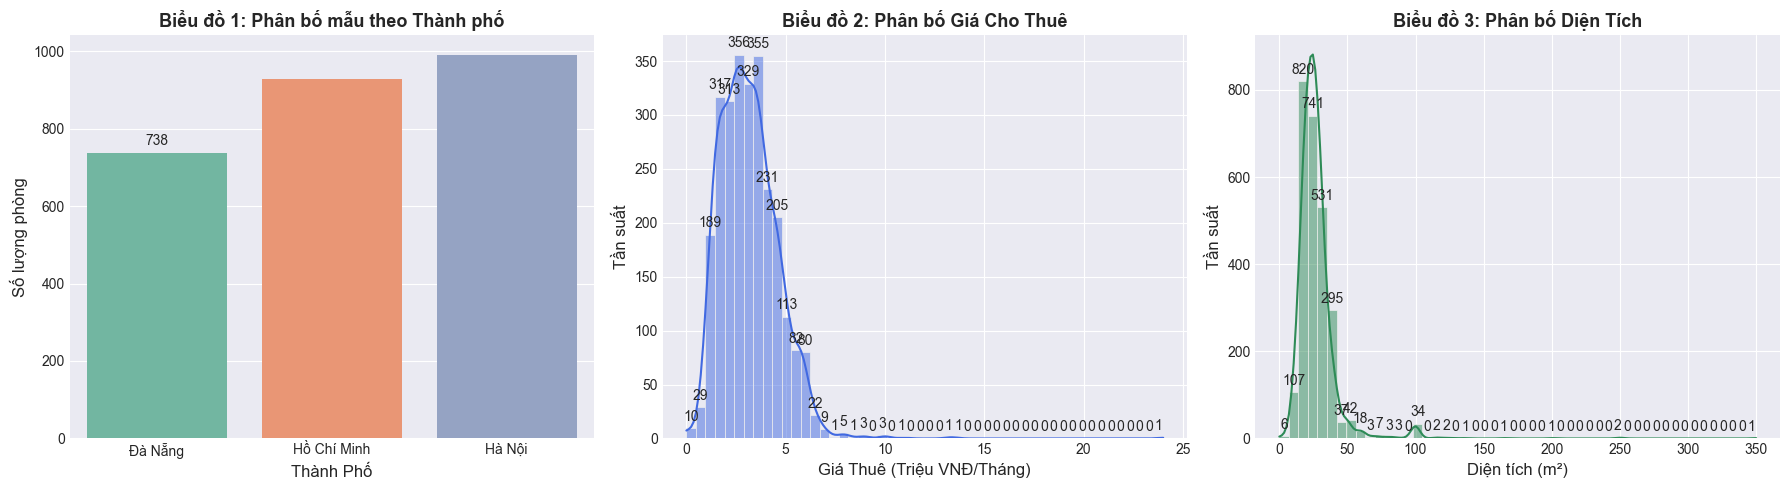

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách biểu đồ
plt.rcParams['font.family'] = 'sans-serif'
plt.style.use('seaborn-v0_8-darkgrid')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Figure 1: Số lượng phòng trọ theo thành phố
sns.countplot(x='Thành_Phố', data=df_raw, palette='Set2', ax=axes[0])
axes[0].set_title('Biểu đồ 1: Phân bố mẫu theo Thành phố', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Số lượng phòng')
axes[0].set_xlabel('Thành Phố')
axes[0].bar_label(axes[0].containers[0], padding=3) # Hiển thị số lượng cụ thể trên đỉnh cột

# Biểu đồ 2: Phân bố Giá cho thuê (Histogram + KDE)
sns.histplot(df_raw['Giá_Cho_Thuê'], bins=50, kde=True, color='royalblue', ax=axes[1])
axes[1].set_title('Biểu đồ 2: Phân bố Giá Cho Thuê', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Giá Thuê (Triệu VNĐ/Tháng)')
axes[1].set_ylabel('Tần suất')
axes[1].bar_label(axes[1].containers[0], padding=3) # Hiển thị số lượng cụ thể trên đỉnh cột

# Biểu đồ 3: Phân bố Diện tích (Histogram + KDE)
sns.histplot(df_raw['Diện_Tích_m2'], bins=50, kde=True, color='seagreen', ax=axes[2])
axes[2].set_title('Biểu đồ 3: Phân bố Diện Tích', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Diện tích (m²)')
axes[2].set_ylabel('Tần suất')
axes[2].bar_label(axes[2].containers[0], padding=3) # Hiển thị số lượng cụ thể trên đỉnh cột

plt.tight_layout()
plt.show()

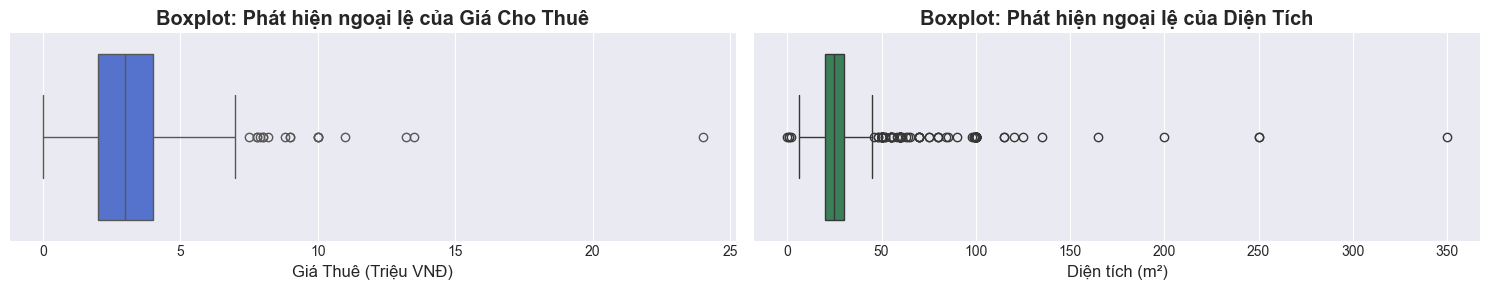

In [25]:
# Khởi tạo khung vẽ gồm 2 biểu đồ Boxplot
fig, axes = plt.subplots(1, 2, figsize=(15, 3))

# Boxplot cho Giá cho thuê
sns.boxplot(x=df_raw['Giá_Cho_Thuê'], color='royalblue', ax=axes[0])
axes[0].set_title('Boxplot: Phát hiện ngoại lệ của Giá Cho Thuê', fontweight='bold')
axes[0].set_xlabel('Giá Thuê (Triệu VNĐ)')

# Boxplot cho Diện tích
sns.boxplot(x=df_raw['Diện_Tích_m2'], color='seagreen', ax=axes[1])
axes[1].set_title('Boxplot: Phát hiện ngoại lệ của Diện Tích', fontweight='bold')
axes[1].set_xlabel('Diện tích (m²)')

plt.tight_layout()
plt.show()

**Nhận xét từ biểu đồ phân tích đơn biến:**

1. **Về phân bổ khu vực (Biểu đồ 1):** Số lượng mẫu thu thập được phân bổ tương đối đồng đều ở các thành phố lớn (Hà Nội, TP.HCM, Đà Nẵng), đảm bảo tính đại diện cho mặt bằng chung của thị trường phòng trọ sinh viên.
2. **Về phân bố hình dáng (Biểu đồ 2 & 3):** - Cả hai biến `Giá_Cho_Thuê` và `Diện_Tích_m2` đều **không tuân theo phân phối chuẩn (Normal Distribution)**. Đường cong KDE cho thấy dữ liệu bị **lệch phải (Right-skewed)** rất nặng.
   - *Nguyên nhân:* Phần lớn phòng trọ sinh viên tập trung ở phân khúc giá rẻ (2 - 5 triệu) và diện tích nhỏ (15 - 30 m²). Tuy nhiên, có một số lượng nhỏ các căn hộ dịch vụ cao cấp hoặc nhà nguyên căn có giá và diện tích kéo dài chiếc "đuôi" của đồ thị về phía bên phải.
3. **Về Ngoại lệ / Outliers (Boxplot):**
   - Biểu đồ Boxplot xuất hiện rất nhiều các điểm đen (outliers) nằm ngoài râu (whiskers) của đồ thị. Tồn tại các điểm dữ liệu bất hợp lý (Giá thuê = 0 đồng, hoặc Diện tích 350 m²). Những dữ liệu rác này nếu đưa thẳng vào mô hình Hồi quy (Regression) sẽ làm giảm độ chính xác và gây ra hiện tượng thiên kiến.

=> **Kết luận & Hành động tiếp theo (Action Plan):**
Để khắc phục các vấn đề trên, lộ trình tiền xử lý tiếp theo của nhóm sẽ bao gồm 3 bước:
- **Bước 1 (Feature Engineering):** "Bóc tách" các cột văn bản (`Mô_Tả`, `Nổi_Bật`) thành các biến định lượng 0/1 trước khi xóa bỏ chúng.
- **Bước 2 (Data Cleaning):** Loại bỏ hoàn toàn các dòng dữ liệu nhiễu (Giá = 0, Diện tích quá vô lý) dựa trên quy tắc cắt xén (Trimming).
- **Bước 3 (Data Transformation):** Áp dụng phép biến đổi Logarit (`np.log1p`) để kéo phân phối của Giá và Diện tích về dạng phân phối chuẩn.

**Nhận xét từ biểu đồ phân tích đơn biến:**

**1. Về phân bổ khu vực (Biều đồ 1):** Số lượng mẫu thu thập được phân bổ tương đối đồng đều ở các thành phố lớn (Hà Nội, TP.HCM, Đà Nẵng), đảm bảo tính đại diện cho mặt bằng chung của thị trường phòng trọ sinh viên.
**2. Về phân bố hình dáng (Biểu đồ 2 & 3):** 
- Cả hai biến `Giá_Cho_Thuê` và `Diện_Tích_m2` đều **không tuân theo phân phối chuẩn (Normal Distribution)**. Đường cong KDE cho thấy dữ liệu bị lệch phải rất nặng.
- Nguyên nhân: Phần lớn phòng trọ sinh viên tập trung ở phân khúc giá rẻ (2 - 5 triệu) và diện tích nhỏ (15 - 30 m2). Tuy nhiên, có một số lượng nhỏ các căn hộ dịch vụ cao cấp hoặc nhà nguyên căn, hoặc đơn giản là dữ liệu bị sai nên giá và diện tích kéo dài chiếc đuôi của đồ thị về phía bên phải.

**3. Về Ngoại lệ / Outlier:**
- Biểu đổ Boxplot xuât hiện rất nhiều điểm đen (outliers) nằm ngoài râu của đồ thị. Tồn tại các điểm dữ liệu bất hợp lý